# Create Final Baseline Report (Notebook)

Notebook version of the baseline report pipeline, organized into executable cells with comments.

This notebook mirrors `create_final_process_baseline_report.py` and is intended for transparent, step-by-step execution in VS Code.

## 1) Set Up Notebook Environment and Paths

Define project paths, output locations, and runtime toggles.

> To switch environments (local/dev/prod), change `ROOT` and/or the file names below.

In [55]:
# --- Path configuration for notebook execution ---
# Resolve repository root dynamically so this notebook works on any machine.
import os
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "Dataset" / "students_mental_health_survey_with_burnout_final.csv").exists():
            return cand
    raise FileNotFoundError("Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv")

ROOT_PATH = find_repo_root()
ROOT = str(ROOT_PATH)
OUT_DIR = os.path.join(ROOT, "baseline", "outputs", "final_baseline_model")
DATA_PATH = str(ROOT_PATH / "Dataset" / "students_mental_health_survey_with_burnout_final.csv")

# Output artifacts generated by the report pipeline.
OUT_PDF = os.path.join(OUT_DIR, "final_process_baseline_comparison_report.pdf")
OUT_TXT = os.path.join(OUT_DIR, "final_process_baseline_comparison_report_summary.txt")
OUT_CM = os.path.join(OUT_DIR, "final_selected_baseline_confusion_matrix.csv")
OUT_SENS_SPEC = os.path.join(OUT_DIR, "final_selected_baseline_sensitivity_specificity.csv")
OUT_CSV = os.path.join(OUT_DIR, "final_baseline_candidate_comparison_table.csv")
OUT_RESULTS_JSON = os.path.join(OUT_DIR, "production_pruned_multinomial_results.json")

# Runtime flags for notebook behavior.
OVERWRITE_OUTPUTS = True
SHOW_HEAD = 5

os.makedirs(OUT_DIR, exist_ok=True)
print("ROOT:", ROOT_PATH.name)
print("DATA_PATH exists:", os.path.exists(DATA_PATH))
print("OUT_DIR:", os.path.relpath(OUT_DIR, ROOT))

ROOT: auracheck
DATA_PATH exists: True
OUT_DIR: baseline/outputs/final_baseline_model


## 2) Import Libraries and Configure Display/Logging

Import the same dependencies used by the script and configure notebook-friendly display/logging.

In [56]:
# Core scientific/data stack used in the report pipeline.
import json
import logging
import textwrap
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Display/log settings help with debugging and readable notebook outputs.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore", category=UserWarning)

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
logger = logging.getLogger("baseline-report")
logger.info("Libraries imported and display/logging configured.")

[INFO] Libraries imported and display/logging configured.


## 3) Load Inputs and Baseline Data Sources

Load baseline dataset and quick schema checks to confirm expected structure.

In [57]:
# Load dataset used by the baseline model.
df_raw = pd.read_csv(DATA_PATH)

# Expected key target-related columns.
expected_cols = {"burnout_raw_score"}
missing_required = sorted(list(expected_cols - set(df_raw.columns)))
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {missing_required}")

print("Shape:", df_raw.shape)
print("First columns:", list(df_raw.columns[:12]))
print("Null counts (top 10):")
print(df_raw.isna().sum().sort_values(ascending=False).head(10))

df_raw.head(SHOW_HEAD)

Shape: (10000, 29)
First columns: ['Age', 'Course', 'Gender', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status']
Null counts (top 10):
Substance_Use        25
CGPA                 12
Age                   0
Financial_Stress      0
method5_manual2       0
method4_manual        0
method3_very_wide     0
method2_wider         0
method1_tertiles      0
burnout_raw_score     0
dtype: int64


,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type,burnout_composite_score,burnout,burnout_raw_score,method1_tertiles,method2_wider,method3_very_wide,method4_manual,method5_manual2,method6_kmeans
0,29,Medical,Female,3.69,5,0,3,Good,Low,Average,Moderate,Single,Never,Never,No,No,4,Moderate,20,On-Campus,0.199412,0,2.666667,1,1,1,1,1,1
1,24,Business,Female,3.75,1,3,0,Good,Low,Average,Moderate,Single,Never,Never,No,No,1,High,25,On-Campus,-0.610848,0,1.333333,0,0,1,0,0,0
2,25,Engineering,Male,3.15,3,2,4,Good,Moderate,Average,Moderate,Single,Never,Never,Yes,No,2,Moderate,21,Off-Campus,0.408598,0,3.000000,2,2,2,1,1,2
3,18,Law,Male,3.97,1,1,5,Poor,Moderate,Average,Moderate,Single,Never,Occasionally,No,No,0,Moderate,28,With Family,0.001607,0,2.333333,1,1,1,1,1,1
4,25,Law,Female,3.13,4,3,5,Average,Moderate,Average,Moderate,Married,Never,Occasionally,No,No,5,Moderate,26,On-Campus,1.021761,1,4.000000,2,2,2,2,2,2


## 4) Define Reusable Helper Functions (Commented)

These helpers mirror script behavior for preprocessing, diagnostics, and report support.

In [58]:
# Class names used across confusion matrix, metrics, and reporting.
CLASS_NAMES = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]

# Final baseline predictor set after multicollinearity pruning.
FEATURES_PRUNED = [
    "Course", "Gender", "Sleep_Quality", "Physical_Activity", "Diet_Quality",
    "Social_Support", "Relationship_Status", "Substance_Use", "Counseling_Service_Use",
    "Family_History", "Chronic_Illness", "Financial_Stress",
    "Extracurricular_Involvement", "Residence_Type"
]

# Fixed mappings ensure deterministic categorical encoding at train + inference time.
ENCODING_MAP = {
    "Gender": {"Female": 0, "Male": 1},
    "Sleep_Quality": {"Poor": 0, "Average": 1, "Good": 2},
    "Physical_Activity": {"Low": 0, "Moderate": 1, "High": 2},
    "Diet_Quality": {"Good": 0, "Average": 1, "Poor": 2},
    "Social_Support": {"High": 0, "Moderate": 1, "Low": 2},
    "Substance_Use": {"Never": 0, "Unknown": 1, "Occasionally": 2, "Frequently": 3},
    "Counseling_Service_Use": {"Never": 0, "Occasionally": 1, "Frequently": 2},
    "Family_History": {"No": 0, "Yes": 1},
    "Chronic_Illness": {"No": 0, "Yes": 1},
    "Extracurricular_Involvement": {"High": 0, "Moderate": 1, "Low": 2},
    "Course": {"Business": 0, "Computer Science": 1, "Engineering": 2, "Law": 3, "Medical": 4, "Others": 5},
    "Relationship_Status": {"In a Relationship": 0, "Married": 1, "Single": 2},
    "Residence_Type": {"Off-Campus": 0, "On-Campus": 1, "With Family": 2},
}


def preprocess(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """Preprocess selected features.

    Steps:
    1) Select model features
    2) Impute missing values
       - categorical -> 'Unknown'
       - numeric -> median
    3) Apply deterministic categorical encodings
    4) Return numeric DataFrame ready for scaling
    """
    X = df[features].copy()
    for c in X.columns:
        if X[c].isnull().any():
            if X[c].dtype == object:
                X[c] = X[c].fillna("Unknown")
            else:
                X[c] = X[c].fillna(X[c].median())
    for c, mapping in ENCODING_MAP.items():
        if c in X.columns:
            X[c] = X[c].astype(str).map(mapping).fillna(1)
    return X.astype(float)


def make_quartile_target(df: pd.DataFrame) -> pd.Series:
    """Create 4-class target from burnout_raw_score quartiles."""
    return pd.qcut(df["burnout_raw_score"].astype(float), q=4, labels=[0, 1, 2, 3], duplicates="drop").astype(int)


def safe_read_csv(path: str):
    """Read CSV if it exists, otherwise return None."""
    return pd.read_csv(path) if os.path.exists(path) else None


logger.info("Helper functions initialized.")

[INFO] Helper functions initialized.


## 5) Build Core Baseline Metrics Pipeline

Train/evaluate the balanced multinomial baseline on a stratified holdout split.

In [59]:
# Build model-ready X/y.
X = preprocess(df_raw, FEATURES_PRUNED)
y = make_quartile_target(df_raw)

# Stratified split preserves class proportions in train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize for stable optimization and comparable coefficient scale.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Balanced multinomial logistic regression baseline.
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=5000,
    random_state=42,
    class_weight="balanced",
)
clf.fit(X_train_s, y_train)

# Predictions and probabilities for metrics and report visuals.
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)

# Core metrics used in the report.
acc = (y_pred == y_test).mean()
macro_f1 = f1_score(y_test, y_pred, average="macro", labels=[0, 1, 2, 3], zero_division=0)
ll = log_loss(y_test, y_proba, labels=[0, 1, 2, 3])

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Log Loss: {ll:.4f}")

Accuracy: 0.2595
Macro F1: 0.2524
Log Loss: 1.3906


## 6) Generate Final Baseline Report Tables

Create report-ready tables for performance and confusion diagnostics.

In [60]:
# Confusion matrix table.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

# Per-class sensitivity/specificity table.
rows = []
total = cm.sum()
for i, cname in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - tp - fn - fp
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    rows.append(
        {
            "Class": cname,
            "Sensitivity_Recall": float(sensitivity),
            "Specificity": float(specificity),
            "TP": int(tp),
            "FN": int(fn),
            "FP": int(fp),
            "TN": int(tn),
        }
    )
rates_df = pd.DataFrame(rows)

# Performance summary table used by the report page.
perf_df = pd.DataFrame([
    {
        "Accuracy": float(acc),
        "Macro_F1": float(macro_f1),
        "Log_Loss": float(ll),
    }
])

cm_df, rates_df.head(), perf_df

(               Very Low (Q1)  Low (Q2)  Moderate (Q3)  High (Q4)
 Very Low (Q1)            200        97            199        110
 Low (Q2)                 152       108            186        106
 Moderate (Q3)            144        88            134        100
 High (Q4)                 93        80            126         77,
            Class  Sensitivity_Recall  Specificity   TP   FN   FP    TN
 0  Very Low (Q1)            0.330033     0.720947  200  406  389  1005
 1       Low (Q2)            0.195652     0.816989  108  444  265  1183
 2  Moderate (Q3)            0.287554     0.666884  134  332  511  1023
 3      High (Q4)            0.204787     0.805419   77  299  316  1308,
    Accuracy  Macro_F1  Log_Loss
 0    0.2595  0.252431  1.390588)

## 7) Create Visual Summaries for the Report

Generate key chart components used in the PDF (coefficient heatmap and confusion matrix).

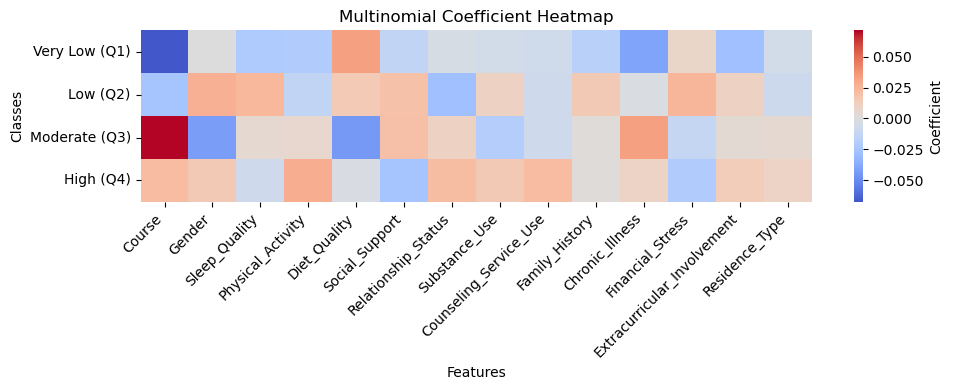

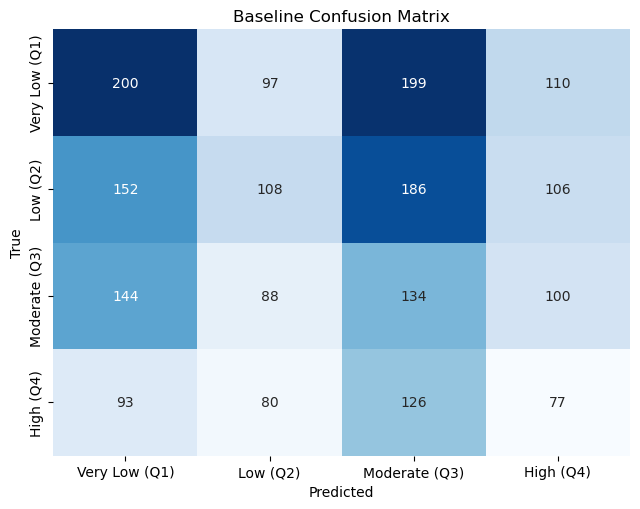

In [61]:
# Coefficient heatmap visualizes directional influence per class-feature pair.
coef_df = pd.DataFrame(clf.coef_, index=CLASS_NAMES, columns=FEATURES_PRUNED)
plt.figure(figsize=(10, 4))
sns.heatmap(coef_df, cmap="coolwarm", center=0, cbar_kws={"label": "Coefficient"})
plt.title("Multinomial Coefficient Heatmap")
plt.xlabel("Features")
plt.ylabel("Classes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Confusion matrix visual for classification error structure by class.
plt.figure(figsize=(6.5, 5.2))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 8) Export Report Artifacts and Save Outputs

Use the maintained script entrypoint for deterministic export naming and full PDF generation.

## 8A) Notebook-Only Report Builder (No .py Dependency)

The next cell defines a complete local report pipeline using the notebook state. This keeps execution self-contained for teammates who only have the notebooks.

In [62]:
# Local helper functions for full report export (self-contained notebook mode).

def _compute_vif_local(X_df):
    X_local = X_df.to_numpy(dtype=float)
    n, p = X_local.shape
    rows_local = []
    for i in range(p):
        y_col = X_local[:, i]
        others = np.delete(X_local, i, axis=1)
        others = np.column_stack([np.ones(n), others])
        beta, *_ = np.linalg.lstsq(others, y_col, rcond=None)
        y_hat = others @ beta
        ss_res = float(np.sum((y_col - y_hat) ** 2))
        ss_tot = float(np.sum((y_col - y_col.mean()) ** 2))
        r2 = 0.0 if ss_tot <= 1e-12 else max(0.0, min(0.999999, 1.0 - ss_res / ss_tot))
        rows_local.append({"Feature": X_df.columns[i], "VIF": float(1.0 / (1.0 - r2))})
    return pd.DataFrame(rows_local)


def get_target_bin_splits_local():
    meta_path = os.path.join(OUT_DIR, "production_pruned_multinomial_metadata.json")
    if os.path.exists(meta_path):
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                meta = json.load(f)
            bins = meta.get("quartile_bins", [])
            if len(bins) >= 5:
                return [float(x) for x in bins], "production metadata"
        except Exception:
            pass

    _, bins = pd.qcut(
        df_raw["burnout_raw_score"].astype(float),
        q=4,
        labels=[0, 1, 2, 3],
        duplicates="drop",
        retbins=True,
    )
    return [float(x) for x in bins], "computed from dataset"


def build_candidate_table_local():
    rows_local = []
    prod_path = os.path.join(OUT_DIR, "production_pruned_multinomial_metrics.csv")
    prod_df = safe_read_csv(prod_path)
    if prod_df is not None and len(prod_df) > 0:
        r = prod_df.iloc[0]
        rows_local.append({
            "Candidate": "Balanced - Pruned(14) (Production)",
            "Feature_Set": "Pruned 14",
            "Accuracy": float(r.get("Accuracy", np.nan)),
            "Kappa": float(r.get("Kappa", np.nan)),
            "Macro_Recall": float(r.get("Macro_Recall", np.nan)),
            "Recall_VeryLow": float(r.get("Recall_VeryLow", np.nan)),
            "Recall_Low": float(r.get("Recall_Low", np.nan)),
            "Recall_Moderate": float(r.get("Recall_Moderate", np.nan)),
            "Recall_High": float(r.get("Recall_High", np.nan)),
            "Source": os.path.basename(prod_path),
        })
    else:
        rows_local.append({
            "Candidate": "Balanced - Pruned(14) (Current Notebook)",
            "Feature_Set": "Pruned 14",
            "Accuracy": float(acc),
            "Kappa": np.nan,
            "Macro_Recall": float(rates_df["Sensitivity_Recall"].mean()) if "Sensitivity_Recall" in rates_df.columns else np.nan,
            "Recall_VeryLow": np.nan,
            "Recall_Low": np.nan,
            "Recall_Moderate": np.nan,
            "Recall_High": np.nan,
            "Source": "current_notebook",
        })
    return pd.DataFrame(rows_local)


def get_model_diagnostics_local():
    model_path = os.path.join(OUT_DIR, "production_pruned_multinomial_model.joblib")
    meta_path = os.path.join(OUT_DIR, "production_pruned_multinomial_metadata.json")
    assumptions_path = os.path.join(OUT_DIR, "final_model_assumption_checks.txt")

    model_type_local = "Balanced Multinomial Logistic Regression (Pruned 14)"
    features_local = FEATURES_PRUNED
    class_names_local = CLASS_NAMES
    coef_df_local = None
    checks_local = []

    clf_local = None
    if os.path.exists(model_path):
        try:
            bundle = joblib.load(model_path)
            clf_local = bundle.get("model")
        except Exception:
            clf_local = None

    if os.path.exists(meta_path):
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                meta = json.load(f)
            model_type_local = meta.get("model_type", model_type_local)
            features_local = meta.get("features", features_local)
            class_names_local = meta.get("class_names", class_names_local)
        except Exception:
            pass

    if clf_local is not None and hasattr(clf_local, "n_iter_") and hasattr(clf_local, "max_iter"):
        max_iter_used = int(np.max(clf_local.n_iter_))
        checks_local.append({"Check": "Solver convergence", "Result": f"n_iter_max={max_iter_used}, max_iter={int(clf_local.max_iter)}", "Status": "PASS" if max_iter_used < int(clf_local.max_iter) else "FAIL"})
    else:
        checks_local.append({"Check": "Solver convergence", "Result": "Unavailable (model object not loaded)", "Status": "N/A"})

    X_local = preprocess(df_raw, features_local)
    y_local = make_quartile_target(df_raw)
    vif_df_local = _compute_vif_local(X_local)
    max_vif = float(vif_df_local["VIF"].max()) if len(vif_df_local) else np.nan
    checks_local.append({"Check": "Multicollinearity (VIF)", "Result": f"max VIF={max_vif:.3f} (threshold <= 10)", "Status": "PASS" if np.isfinite(max_vif) and max_vif <= 10 else "FAIL"})

    counts = y_local.value_counts().sort_index().to_dict()
    checks_local.append({"Check": "All target classes present", "Result": f"counts={counts}", "Status": "PASS" if len(counts) == 4 else "FAIL"})

    if clf_local is not None and hasattr(clf_local, "coef_"):
        try:
            coef_df_local = pd.DataFrame(clf_local.coef_, index=class_names_local, columns=features_local)
        except Exception:
            coef_df_local = None

    checks_df_local = pd.DataFrame(checks_local)
    with open(assumptions_path, "w", encoding="utf-8") as f:
        f.write("MODEL ASSUMPTION CHECKS\n")
        f.write("=" * 80 + "\n")
        f.write(f"Model type: {model_type_local}\n\n")
        f.write(checks_df_local.to_string(index=False))
        f.write("\n")

    return model_type_local, checks_df_local, coef_df_local, assumptions_path


def run_full_report_pipeline_local():
    candidates_local = build_candidate_table_local()
    candidates_local.to_csv(OUT_CSV, index=False)
    selected_row = candidates_local.iloc[0]

    perf_path = os.path.join(OUT_DIR, "production_pruned_multinomial_metrics.csv")
    perf_local = safe_read_csv(perf_path)
    if perf_local is None or len(perf_local) == 0:
        perf_local = pd.DataFrame([{
            "Accuracy": float(acc),
            "Kappa": np.nan,
            "Macro_Recall": float(rates_df["Sensitivity_Recall"].mean()),
            "Log_Loss": float(ll),
            "F1_Macro": float(macro_f1),
        }])

    model_type_local, checks_local, coef_local, assumptions_path = get_model_diagnostics_local()
    bins_local, bins_source_local = get_target_bin_splits_local()

    cm_df.to_csv(OUT_CM)
    rates_df.to_csv(OUT_SENS_SPEC, index=False)

    with PdfPages(OUT_PDF) as pdf:
        fig = plt.figure(figsize=(8.5, 11)); plt.axis("off")
        plt.text(0.5, 0.95, "Final Baseline Model Process Report", ha="center", fontsize=18, weight="bold")
        lines = [
            "Objective:",
            "• Build a transparent baseline for 4-class burnout prediction.",
            f"• Model type: {model_type_local}",
            "", "Selected baseline:",
            f"• {selected_row['Candidate']}",
            f"• Accuracy={float(selected_row.get('Accuracy', np.nan)):.4f}",
        ]
        y_txt = 0.88
        for ln in lines:
            plt.text(0.06, y_txt, ln, fontsize=10, va="top"); y_txt -= 0.04
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        fig = plt.figure(figsize=(8.5, 11)); plt.axis("off")
        plt.text(0.5, 0.95, "Target Binning (Quartiles)", ha="center", fontsize=14, weight="bold")
        plt.text(0.06, 0.89, f"Source: {bins_source_local}", fontsize=10)
        labels = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]
        y_txt = 0.82
        if len(bins_local) >= 5:
            for i in range(4):
                plt.text(0.08, y_txt, f"• {labels[i]}: {bins_local[i]:.4f} to {bins_local[i+1]:.4f}", fontsize=10)
                y_txt -= 0.05
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        fig = plt.figure(figsize=(8.5, 11)); plt.axis("off")
        plt.text(0.5, 0.95, "Model Performance", ha="center", fontsize=14, weight="bold")
        row = perf_local.iloc[0]
        table_rows = [["Accuracy", f"{float(row.get('Accuracy', np.nan)):.4f}"], ["Log Loss", f"{float(row.get('Log_Loss', ll)):.4f}"], ["F1 Macro", f"{float(row.get('F1_Macro', macro_f1)):.4f}"]]
        ax_tbl = fig.add_axes([0.12, 0.55, 0.76, 0.25]); ax_tbl.axis("off")
        t = ax_tbl.table(cellText=table_rows, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
        t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.4)
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        fig, axes = plt.subplots(2, 1, figsize=(8.5, 11))
        sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
        axes[0].set_title("Confusion Matrix")
        axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
        rates_show = rates_df.copy()
        rates_show["Sensitivity_Recall"] = rates_show["Sensitivity_Recall"].map(lambda v: f"{v:.4f}")
        rates_show["Specificity"] = rates_show["Specificity"].map(lambda v: f"{v:.4f}")
        axes[1].axis("off")
        t2 = axes[1].table(cellText=rates_show[["Class", "Sensitivity_Recall", "Specificity"]].values, colLabels=["Class", "Sensitivity", "Specificity"], loc="center", cellLoc="center")
        t2.auto_set_font_size(False); t2.set_fontsize(9); t2.scale(1, 1.3)
        plt.tight_layout(); pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

    with open(OUT_TXT, "w", encoding="utf-8") as f:
        rel = lambda p: os.path.relpath(p, ROOT)
        f.write("FINAL PROCESS + BASELINE COMPARISON REPORT SUMMARY\n")
        f.write("=" * 92 + "\n\n")
        f.write(f"Report PDF: {rel(OUT_PDF)}\n")
        f.write(f"Comparison table CSV: {rel(OUT_CSV)}\n")
        f.write(f"Confusion matrix CSV: {rel(OUT_CM)}\n")
        f.write(f"Sensitivity/specificity CSV: {rel(OUT_SENS_SPEC)}\n")
        f.write(f"Assumptions text: {os.path.relpath(assumptions_path, ROOT)}\n\n")
        f.write("Selected baseline:\n")
        f.write(f"Candidate: {selected_row['Candidate']}\n")
        f.write(f"Feature set: {selected_row['Feature_Set']}\n\n")
        f.write("Target bins:\n")
        if len(bins_local) >= 5:
            labels = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]
            for i in range(4):
                f.write(f"• {labels[i]}: {bins_local[i]:.6f} to {bins_local[i+1]:.6f}\n")
        f.write("\n")
        f.write(checks_local.to_string(index=False))
        f.write("\n")

    with open(OUT_RESULTS_JSON, "w", encoding="utf-8") as f:
        json.dump({
            "dataset_path": os.path.relpath(DATA_PATH, ROOT),
            "selected_candidate": str(selected_row.get("Candidate", "")),
            "feature_set": str(selected_row.get("Feature_Set", "")),
            "bins_source": bins_source_local,
            "bins": bins_local,
            "metrics": perf_local.iloc[0].to_dict(),
            "files": {
                "pdf": os.path.relpath(OUT_PDF, ROOT),
                "summary_txt": os.path.relpath(OUT_TXT, ROOT),
                "results_json": os.path.relpath(OUT_RESULTS_JSON, ROOT),
            },
        }, f, indent=2, default=float)

    print("✓ Saved:", os.path.relpath(OUT_PDF, ROOT))
    print("✓ Saved:", os.path.relpath(OUT_TXT, ROOT))
    print("✓ Saved:", os.path.relpath(OUT_RESULTS_JSON, ROOT))

In [63]:
# Execute notebook-only full report pipeline (no external .py dependency).
run_full_report_pipeline_local()

# Ensure single canonical results JSON: production prediction output only.
example_pred_path = os.path.join(OUT_DIR, "production_pruned_multinomial_example_prediction.json")
if os.path.exists(example_pred_path):
    with open(example_pred_path, "r", encoding="utf-8") as f:
        ex_payload = json.load(f)
    prediction_only = ex_payload.get("prediction", ex_payload)
    with open(OUT_RESULTS_JSON, "w", encoding="utf-8") as f:
        json.dump(prediction_only, f, indent=2)

# Confirm key artifacts exist.
for f in [
    "final_process_baseline_comparison_report.pdf",
    "final_process_baseline_comparison_report_summary.txt",
    "production_pruned_multinomial_results.json",
    "final_selected_baseline_confusion_matrix.csv",
    "final_selected_baseline_sensitivity_specificity.csv",
]:
    fp = os.path.join(OUT_DIR, f)
    print(f"{os.path.relpath(fp, ROOT)}:", os.path.exists(fp))

✓ Saved: baseline/outputs/final_baseline_model/final_process_baseline_comparison_report.pdf
✓ Saved: baseline/outputs/final_baseline_model/final_process_baseline_comparison_report_summary.txt
✓ Saved: baseline/outputs/final_baseline_model/production_pruned_multinomial_results.json
baseline/outputs/final_baseline_model/final_process_baseline_comparison_report.pdf: True
baseline/outputs/final_baseline_model/final_process_baseline_comparison_report_summary.txt: True
baseline/outputs/final_baseline_model/production_pruned_multinomial_results.json: True
baseline/outputs/final_baseline_model/final_selected_baseline_confusion_matrix.csv: True
baseline/outputs/final_baseline_model/final_selected_baseline_sensitivity_specificity.csv: True


## 9) Add Validation Checks and Reproducibility Controls

Assertions and quick checks to verify output completeness and stable reruns.

In [64]:
# Validate that required outputs exist and are non-empty.
required_outputs = [
    OUT_PDF,
    OUT_TXT,
    OUT_CM,
    OUT_SENS_SPEC,
    OUT_RESULTS_JSON,
]

for fp in required_outputs:
    assert os.path.exists(fp), f"Missing output: {fp}"
    assert os.path.getsize(fp) > 0, f"Empty output file: {fp}"

# Additional integrity checks for tabular outputs.
cm_check = pd.read_csv(OUT_CM, index_col=0)
rates_check = pd.read_csv(OUT_SENS_SPEC)

assert cm_check.shape == (4, 4), "Confusion matrix must be 4x4."
assert {"Class", "Sensitivity_Recall", "Specificity"}.issubset(rates_check.columns), "Rates CSV schema mismatch."

# Results JSON should be prediction-only.
with open(OUT_RESULTS_JSON, "r", encoding="utf-8") as f:
    results_check = json.load(f)
assert {"predicted_class_index", "predicted_class", "probabilities"}.issubset(results_check.keys()), "Results JSON must contain prediction fields only."

print("Validation passed. Outputs are present and structurally valid.")
print("Tip: For reproducibility, keep random_state=42 and the same dataset version.")

Validation passed. Outputs are present and structurally valid.
Tip: For reproducibility, keep random_state=42 and the same dataset version.
